# Giai đoạn 2: Phân tích Khám phá Dữ liệu và Trực quan hóa
Khám phá dữ liệu để xác định các đặc điểm kinh tế - xã hội liên quan đến tỷ lệ tội phạm bạo lực tại Hoa Kỳ.
Đồng thời, thông qua hệ số tương quan Pearson và trực quan hóa để giải đáp 5 giả thuyết kinh tế - xã hội:
1. **Tuổi tác:** Dân số trẻ có làm tăng tội phạm?
2. **Giáo dục:** Học vấn cao có giúp kìm hãm bạo lực?
3. **Kinh tế:** Nghèo đói có tạo ra "căng thẳng xã hội" dẫn đến tội phạm?
4. **Nhập cư:** Cộng đồng nhập cư có thực sự tỷ lệ thuận với tội phạm?
5. **Dân tộc:** Yếu tố sắc tộc có mối liên hệ nào với an ninh cộng đồng?

In [5]:
# ==========================================
# IMPORT THƯ VIỆN VÀ TẢI DỮ LIỆU
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập giao diện cho đồ thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

try:
    df = pd.read_csv('../data/processed/cleaned_crime_data_183.csv')
except FileNotFoundError:
    df = pd.read_csv('cleaned_crime_data_183.csv')

print(f"Kích thước tập dữ liệu phục vụ EDA: {df.shape}")

TARGET = 'ViolentCrimesPerPop'

Kích thước tập dữ liệu phục vụ EDA: (1994, 101)


## 1. Phân tích Phân phối Biến mục tiêu (Target Analysis)

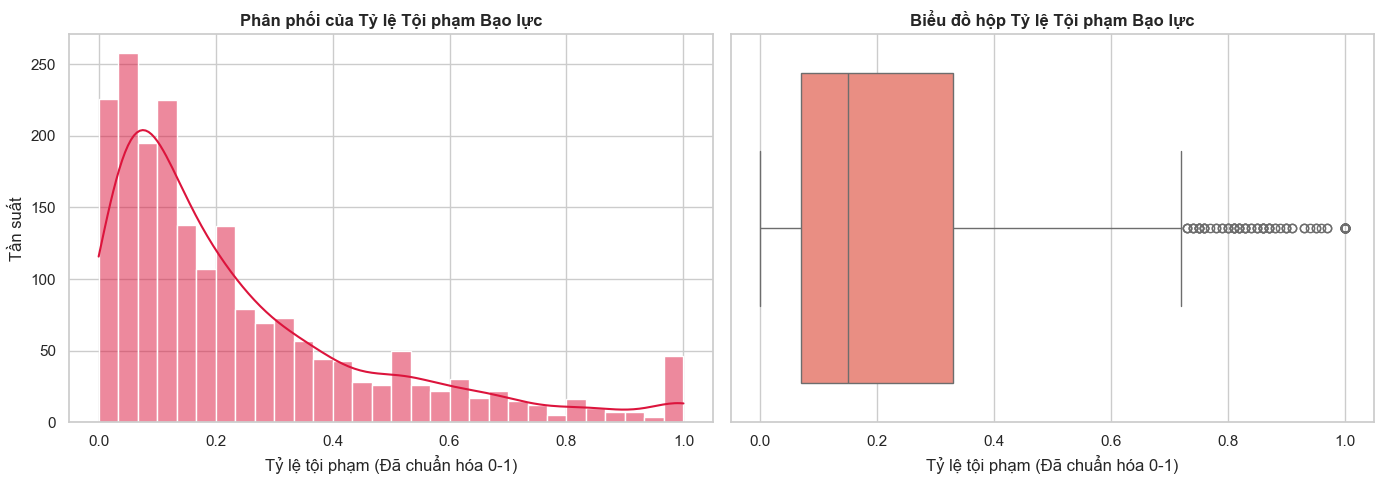

Thống kê mô tả của biến mục tiêu:
count    1994.000000
mean        0.237979
std         0.232985
min         0.000000
25%         0.070000
50%         0.150000
75%         0.330000
max         1.000000
Name: ViolentCrimesPerPop, dtype: float64


In [6]:
plt.figure(figsize=(14, 5))

# Trực quan hóa phân phối của biến mục tiêu
plt.subplot(1, 2, 1)
sns.histplot(df[TARGET], kde=True, color='crimson', bins=30)
plt.title('Phân phối của Tỷ lệ Tội phạm Bạo lực', fontweight='bold')
plt.xlabel('Tỷ lệ tội phạm (Đã chuẩn hóa 0-1)')
plt.ylabel('Tần suất')

# Biểu đồ phát hiện ngoại lai trực quan
plt.subplot(1, 2, 2)
sns.boxplot(x=df[TARGET], color='salmon')
plt.title('Biểu đồ hộp Tỷ lệ Tội phạm Bạo lực', fontweight='bold')
plt.xlabel('Tỷ lệ tội phạm (Đã chuẩn hóa 0-1)')

plt.tight_layout()
plt.show()

print("Thống kê mô tả của biến mục tiêu:")
print(df[TARGET].describe())

## 2. Kiểm định 5 Giả thuyết Kinh tế - Xã hội

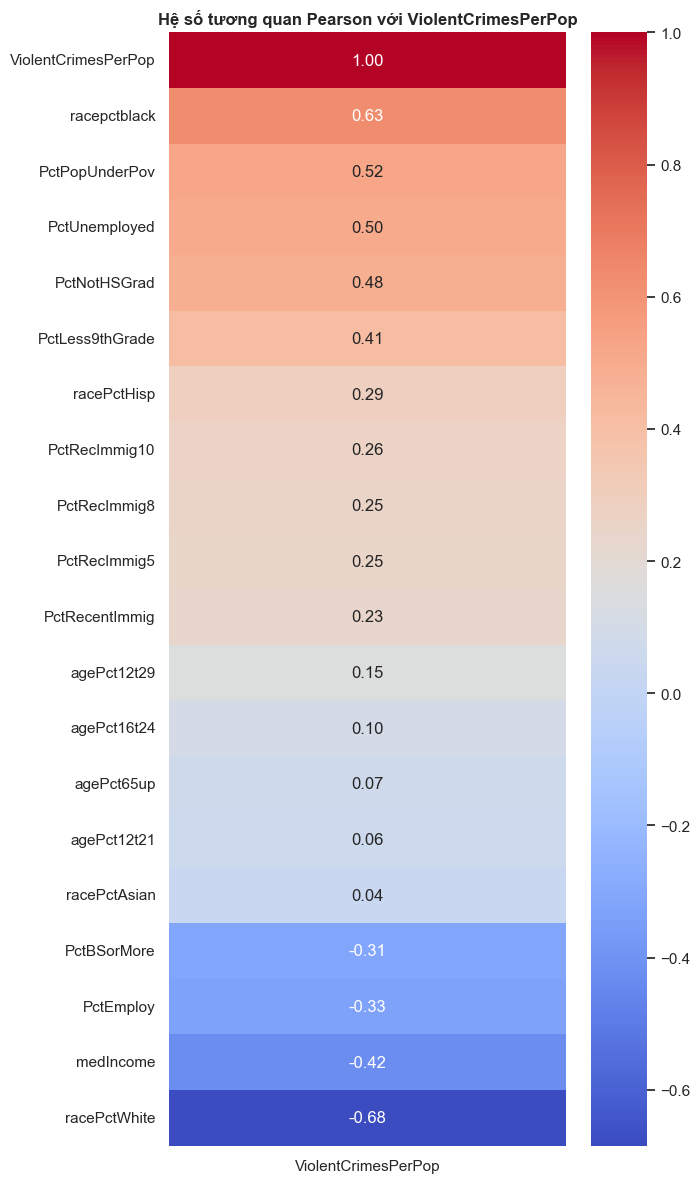

In [7]:
hypotheses_vars = {
    "Tuổi tác": ['agePct12t21', 'agePct12t29', 'agePct16t24', 'agePct65up'],
    "Giáo dục": ['PctLess9thGrade', 'PctNotHSGrad', 'PctBSorMore'],
    "Kinh tế": ['medIncome', 'PctPopUnderPov', 'PctUnemployed', 'PctEmploy'],
    "Nhập cư": ['PctRecentImmig', 'PctRecImmig5', 'PctRecImmig8', 'PctRecImmig10'],
    "Sắc tộc": ['racepctblack', 'racePctWhite', 'racePctAsian', 'racePctHisp']
}

all_selected_vars = []
for vars_list in hypotheses_vars.values():
    all_selected_vars.extend(vars_list)
all_selected_vars.append(TARGET)

corr_matrix = df[all_selected_vars].corr()

# Vẽ Heatmap tương quan với biến mục tiêu
plt.figure(figsize=(7, 12))
target_corr = corr_matrix[[TARGET]].sort_values(by=TARGET, ascending=False)
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title('Hệ số tương quan Pearson với ViolentCrimesPerPop', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Trực quan chi tiết các yếu tố ảnh hưởng mạnh nhất

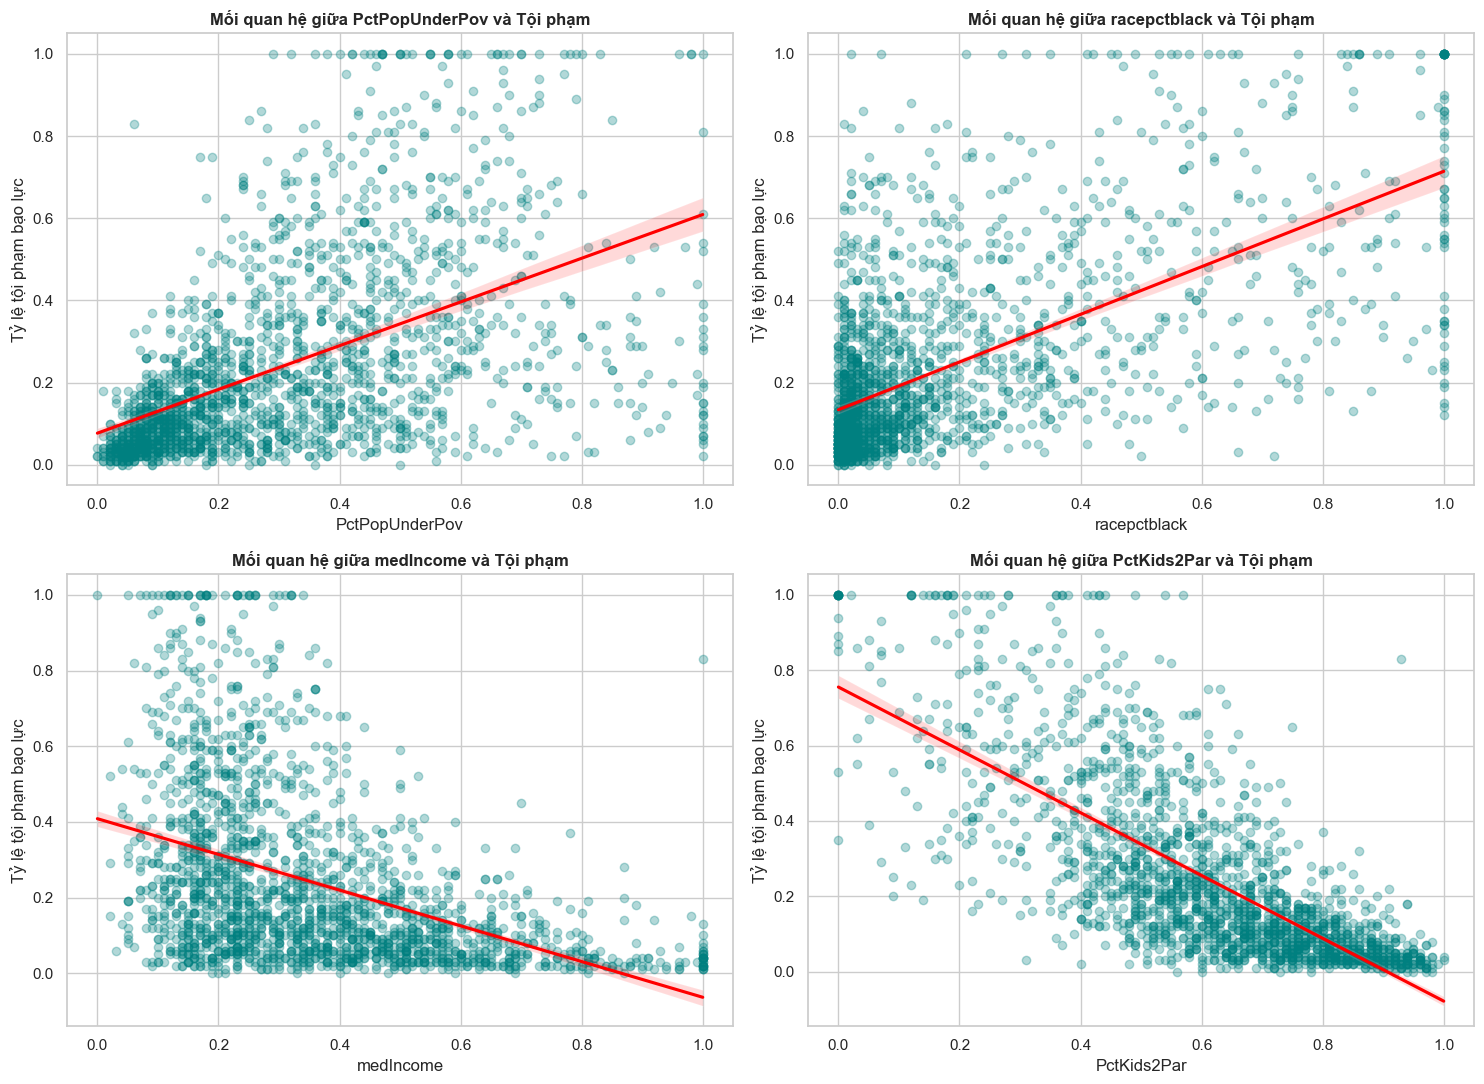

In [8]:
# Chọn ra các biến tiêu biểu có tương quan mạnh để trực quan hóa
top_features = ['PctPopUnderPov', 'racepctblack', 'medIncome', 'PctKids2Par']

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
axes = axes.flatten()

for i, col in enumerate(top_features):
    if col in df.columns:
        sns.regplot(data=df, x=col, y=TARGET, ax=axes[i], 
                    scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})
        axes[i].set_title(f'Mối quan hệ giữa {col} và Tội phạm', fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Tỷ lệ tội phạm bạo lực')

plt.tight_layout()
plt.show()